# 08 · Explainability

What the models rely on, and whether different methods agree. These methods explain the models, not the biology.

| Method | Model |
|---|---|
| Odds ratios | L1 logistic |
| Hazard ratios | Coxnet |
| Permutation importance (Breiman, 2001) | both |
| SHAP (Lundberg & Lee, 2017) | XGBoost |

In [1]:
import sys, warnings, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score
from sksurv.metrics import concordance_index_censored

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.features import INPUT_COLS
from seer_survival.inference import SeerPredictor
from seer_survival.targets import make_surv
from seer_survival.training import make_split, horizon_subset, fit_final_classifier
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
df = load_clean()
s = make_split(df)
Xtr_h, ytr_h, _ = horizon_subset(s["X_train"], s["t_train"], s["e_train"])
Xte_h, yte_h, _ = horizon_subset(s["X_test"], s["t_test"], s["e_test"])
pred = SeerPredictor.load()
clf, surv = pred.classifier, pred.survival
print("classifier:", pred.metadata["classifier_name"], "| survival:", pred.metadata["survival_model_name"])

classifier: LogReg (L1) | survival: Coxnet (elastic net)


## 1. Odds ratios

Numeric and ordinal inputs are standardised, so ORs are per standard deviation. L1 sets weak coefficients to zero.

7 of 23 coefficients shrunk to exactly zero by L1: ['marital_status_Divorced', 'nodes_examined', 'hr_status_ER+/PR-', 'marital_status_Widowed', 'hr_status_ER-/PR+', 'hr_status_ER-/PR-', 'marital_status_Single']


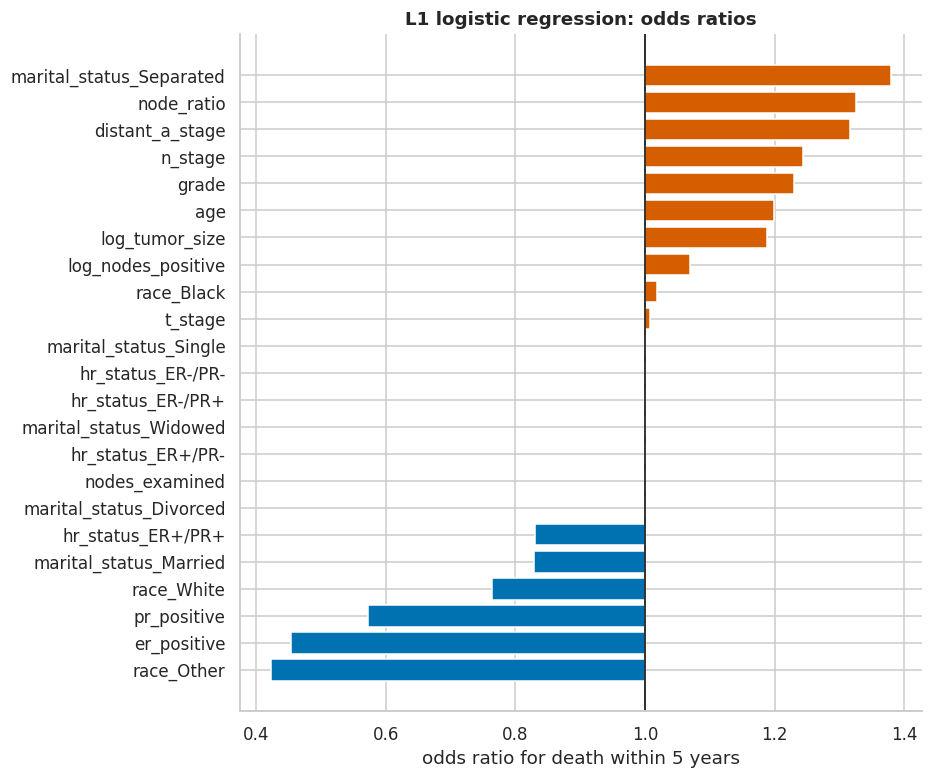

In [2]:
names = clf.named_steps["prep"].named_steps["encode"].get_feature_names_out()
coef = clf.named_steps["model"].coef_.ravel()
orr = pd.DataFrame({"feature": names, "coef": coef, "odds_ratio": np.exp(coef)}).sort_values("coef")
print(f"{(coef == 0).sum()} of {len(coef)} coefficients shrunk to exactly zero by L1:",
      orr.loc[orr.coef == 0, "feature"].tolist())
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(orr.feature, orr.odds_ratio - 1, left=1, color=np.where(orr.coef > 0, PALETTE[1], PALETTE[0]))
ax.axvline(1, c="k", lw=1); ax.set_xlabel("odds ratio for death within 5 years")
ax.set_title("L1 logistic regression: odds ratios")
save_fig(fig, "08_logreg_odds_ratios"); plt.show()

## 2. Coxnet: hazard ratios

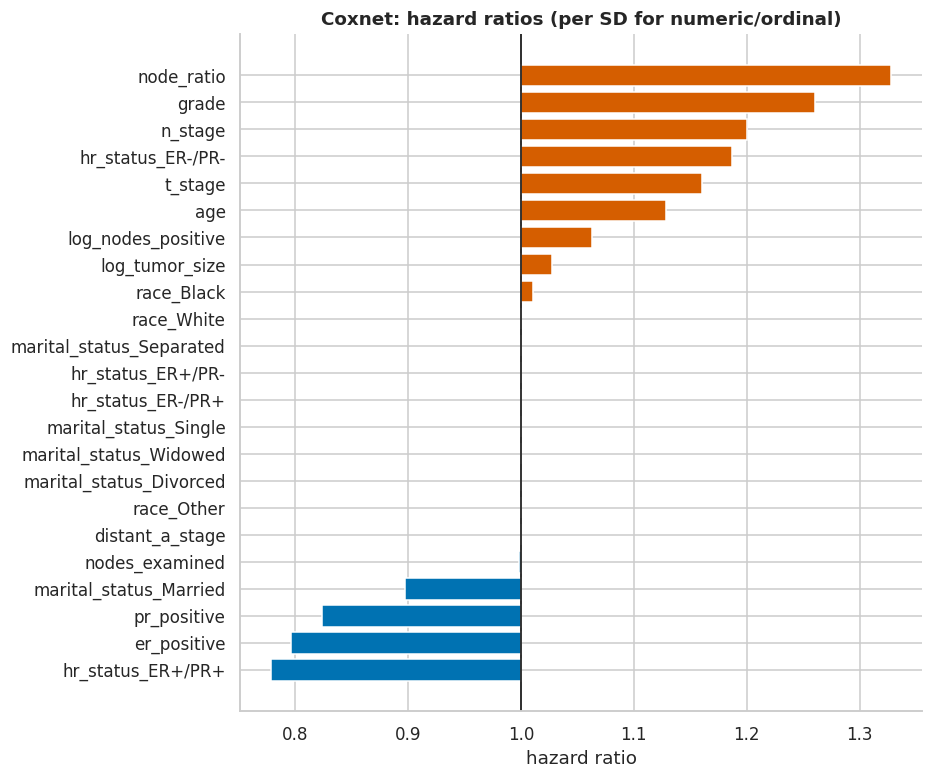

In [3]:
cox = surv.named_steps["model"]
snames = surv.named_steps["prep"].named_steps["encode"].get_feature_names_out()
hr = pd.DataFrame({"feature": snames, "coef": cox.coef_.ravel(), "hazard_ratio": np.exp(cox.coef_.ravel())}).sort_values("coef")
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(hr.feature, hr.hazard_ratio - 1, left=1, color=np.where(hr.coef > 0, PALETTE[1], PALETTE[0]))
ax.axvline(1, c="k", lw=1); ax.set_xlabel("hazard ratio")
ax.set_title("Coxnet: hazard ratios (per SD for numeric/ordinal)")
save_fig(fig, "08_coxnet_hazard_ratios"); plt.show()

## 3. Permutation importance (test split)

Each raw input is shuffled 30 times and the drop in AUC or C-index is recorded. Features derived from an input move with it.

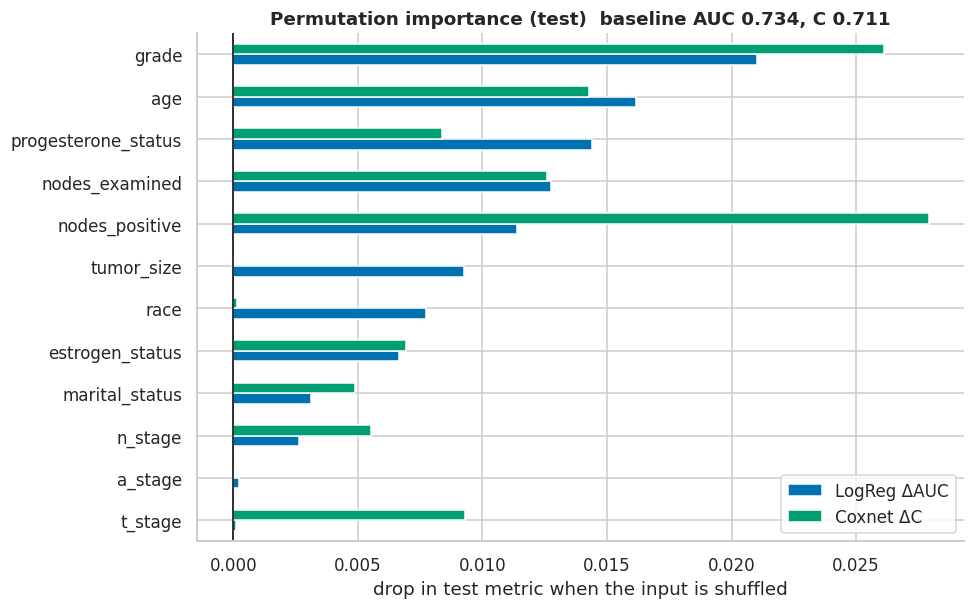

,LogReg ΔAUC,Coxnet ΔC
grade,0.0210,0.0261
age,0.0162,0.0143
progesterone_status,0.0144,0.0084
nodes_examined,0.0128,0.0126
nodes_positive,0.0114,0.0279
tumor_size,0.0092,-0.0001
race,0.0077,0.0002
estrogen_status,0.0066,0.0069
marital_status,0.0031,0.0049
n_stage,0.0026,0.0055


In [4]:
rng = np.random.default_rng(C.RANDOM_STATE)
def perm_importance(score_fn, X, n_rep=30):
    base = score_fn(X)
    out = {}
    for c in INPUT_COLS:
        drops = []
        for _ in range(n_rep):
            Xp = X.copy()
            Xp[c] = rng.permutation(Xp[c].to_numpy())
            if c in ("nodes_positive", "nodes_examined"):   # keep positive <= examined
                Xp["nodes_positive"] = np.minimum(Xp["nodes_positive"], Xp["nodes_examined"])
            drops.append(base - score_fn(Xp))
        out[c] = (np.mean(drops), np.std(drops))
    return base, pd.DataFrame(out, index=["mean_drop", "sd"]).T

y_te_s = make_surv(s["t_test"], s["e_test"])
auc_fn = lambda X: roc_auc_score(yte_h, clf.predict_proba(X)[:, 1])
c_fn = lambda X: concordance_index_censored(y_te_s["event"], y_te_s["time"], surv.predict(X))[0]
b1, pi_clf = perm_importance(auc_fn, Xte_h)
b2, pi_cox = perm_importance(c_fn, s["X_test"])
pi = pd.DataFrame({"LogReg ΔAUC": pi_clf.mean_drop, "Coxnet ΔC": pi_cox.mean_drop}).sort_values("LogReg ΔAUC")
fig, ax = plt.subplots(figsize=(9, 6))
pi.plot.barh(ax=ax, color=[PALETTE[0], PALETTE[2]])
ax.axvline(0, c="k", lw=1); ax.set_xlabel("drop in test metric when the input is shuffled")
ax.set_title(f"Permutation importance (test)  baseline AUC {b1:.3f}, C {b2:.3f}")
save_fig(fig, "08_permutation_importance"); plt.show()
pi.sort_values("LogReg ΔAUC", ascending=False).round(4)

## 4. SHAP for XGBoost

Does a flexible model rely on the same variables as the linear ones?

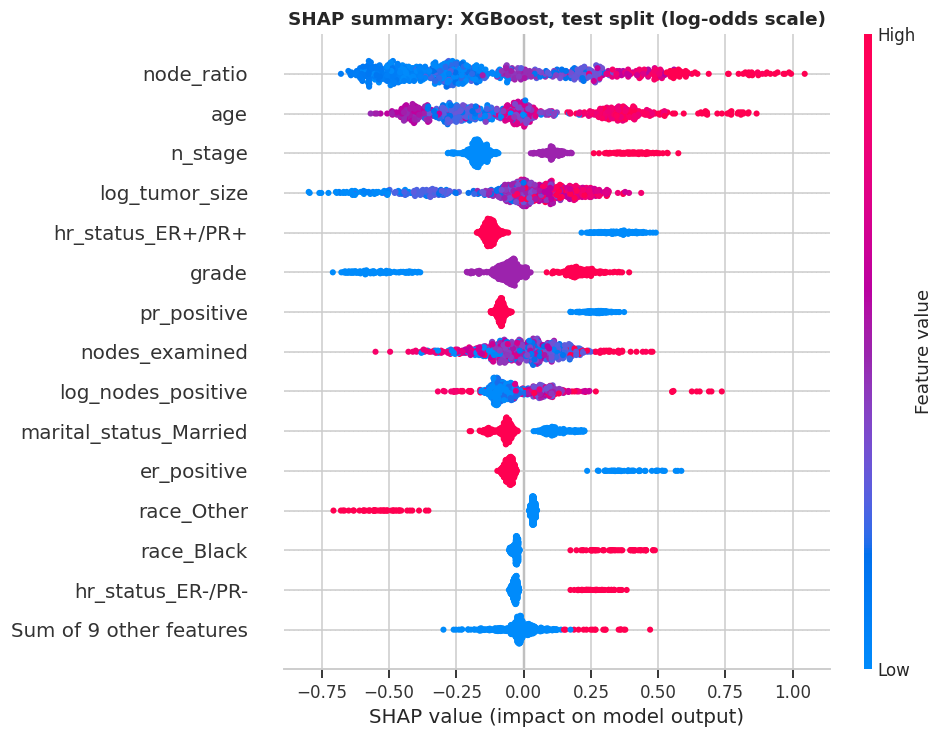

In [5]:
xgb_pipe = fit_final_classifier("XGBoost", Xtr_h, ytr_h)
Xte_enc = xgb_pipe.named_steps["prep"].transform(Xte_h)
explainer = shap.TreeExplainer(xgb_pipe.named_steps["model"])
sv = explainer(Xte_enc)
plt.figure()
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP summary: XGBoost, test split (log-odds scale)")
save_fig(plt.gcf(), "08_shap_beeswarm"); plt.show()

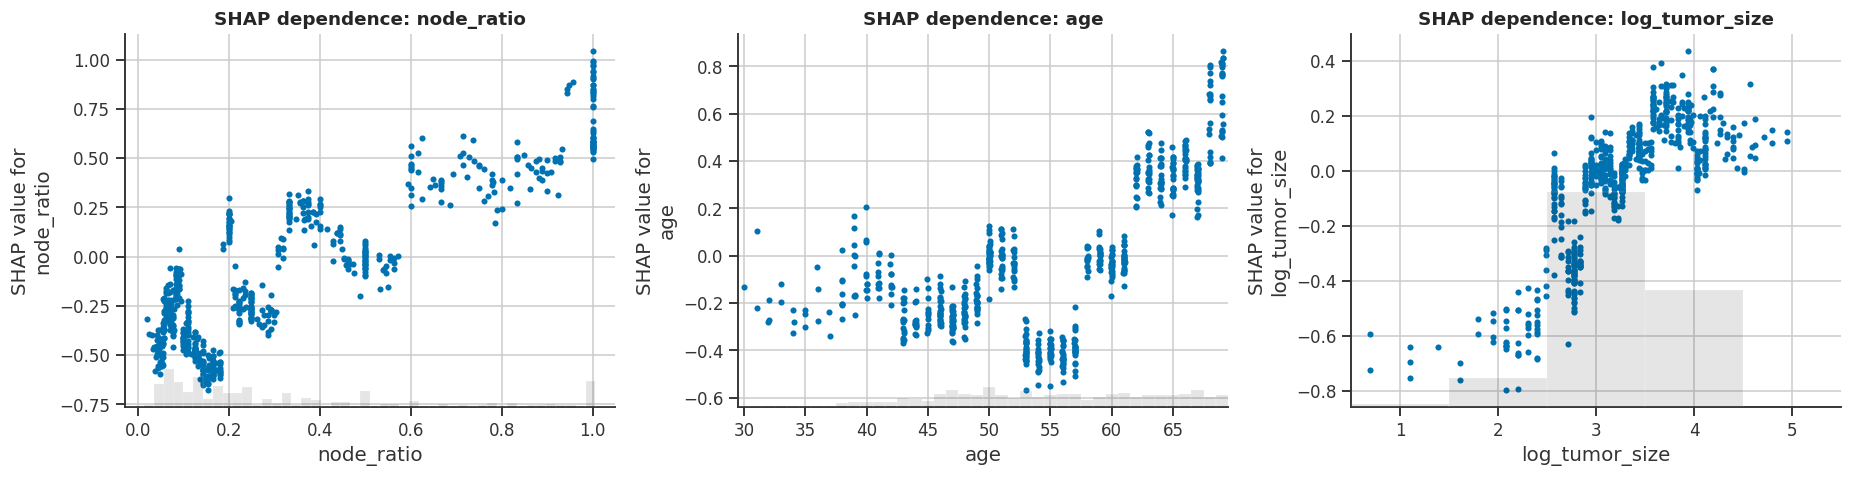

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, f in zip(axes, ["node_ratio", "age", "log_tumor_size"]):
    shap.plots.scatter(sv[:, f], ax=ax, show=False, color=PALETTE[0])
    ax.set_title(f"SHAP dependence: {f}")
fig.tight_layout(); save_fig(fig, "08_shap_dependence"); plt.show()

## 5. Do the methods agree?

Rank correlation between importance rankings. SHAP importance (mean |SHAP|) is summed back to the raw input it came from, so all rankings are over the same 12 clinical variables.

In [7]:
to_raw = {"age": "age", "log_tumor_size": "tumor_size", "nodes_examined": "nodes_examined",
          "log_nodes_positive": "nodes_positive", "node_ratio": "nodes_positive",
          "t_stage": "t_stage", "n_stage": "n_stage", "grade": "grade", "er_positive": "estrogen_status",
          "pr_positive": "progesterone_status", "distant_a_stage": "a_stage"}
shap_imp = pd.Series(np.abs(sv.values).mean(0), index=Xte_enc.columns)
raw_imp = {}
for f, v in shap_imp.items():
    key = to_raw.get(f) or ("race" if f.startswith("race") else "marital_status" if f.startswith("marital")
                            else "estrogen_status" if f.startswith("hr_status") else f)
    raw_imp[key] = raw_imp.get(key, 0) + v
imp = pd.DataFrame({"LogReg perm": pi_clf.mean_drop, "Coxnet perm": pi_cox.mean_drop,
                    "XGBoost |SHAP|": pd.Series(raw_imp)}).loc[INPUT_COLS]
print("Spearman rank correlation of importance rankings:")
imp.rank(ascending=False).corr(method="spearman").round(2)

Spearman rank correlation of importance rankings:


,LogReg perm,Coxnet perm,XGBoost |SHAP|
LogReg perm,1.00,0.56,0.38
Coxnet perm,0.56,1.00,0.29
XGBoost |SHAP|,0.38,0.29,1.00


In [8]:
imp.rank(ascending=False).astype(int).sort_values("LogReg perm")

,LogReg perm,Coxnet perm,XGBoost |SHAP|
grade,1,2,6
age,2,3,3
progesterone_status,3,6,8
nodes_examined,4,4,10
nodes_positive,5,1,1
tumor_size,6,12,5
race,7,10,7
estrogen_status,8,7,2
marital_status,9,9,9
n_stage,10,8,4


(`hr_status` SHAP is attributed to `estrogen_status` for simplicity; it is built from ER and PR together.)

## Findings

- Nodal burden is the main signal: ranked 1st by Coxnet and XGBoost. In the logistic model the credit is split with `nodes_examined` through `node_ratio`.
- Age ranks 2nd–3rd in all models. Grade and ER/PR status are in the top half.
- `a_stage` and `marital_status` add little.
- Rank agreement between methods is moderate (Spearman 0.29–0.56). Most disagreement is within correlated pairs (`t_stage`/`tumor_size`, `n_stage`/`nodes_positive`), where credit can go to either member.
- SHAP: risk rises with node ratio; with tumour size up to about 40 mm, then levels off; and is highest at age 60+. The small wiggles are likely noise.
- These are the established prognostic factors used in AJCC staging and PREDICT (Wishart et al., 2010).